In [55]:
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from models.DopplerDataset import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
LABELS     = ['W', 'E', 'R', 'J', 'L']
ACTIVITIES = ['Walking', 'Empty', 'Running', 'Jumping', 'Sitting']

labels_map = {label:idx for idx, label in enumerate(LABELS)}

train_dataset  = DopplerDataset("doppler_traces_test", labels_map)
train_dataset.getInfo()

Loading dataset doppler_traces_test in memory...


2816it [00:01, 1727.17it/s]

Dataset is loaded!

---------- DATASET INFO ----------
Dataset directory:
doppler_traces_test
Labels dictionary:
{'W': 0, 'E': 1, 'R': 2, 'J': 3, 'L': 4}
----------------------------------



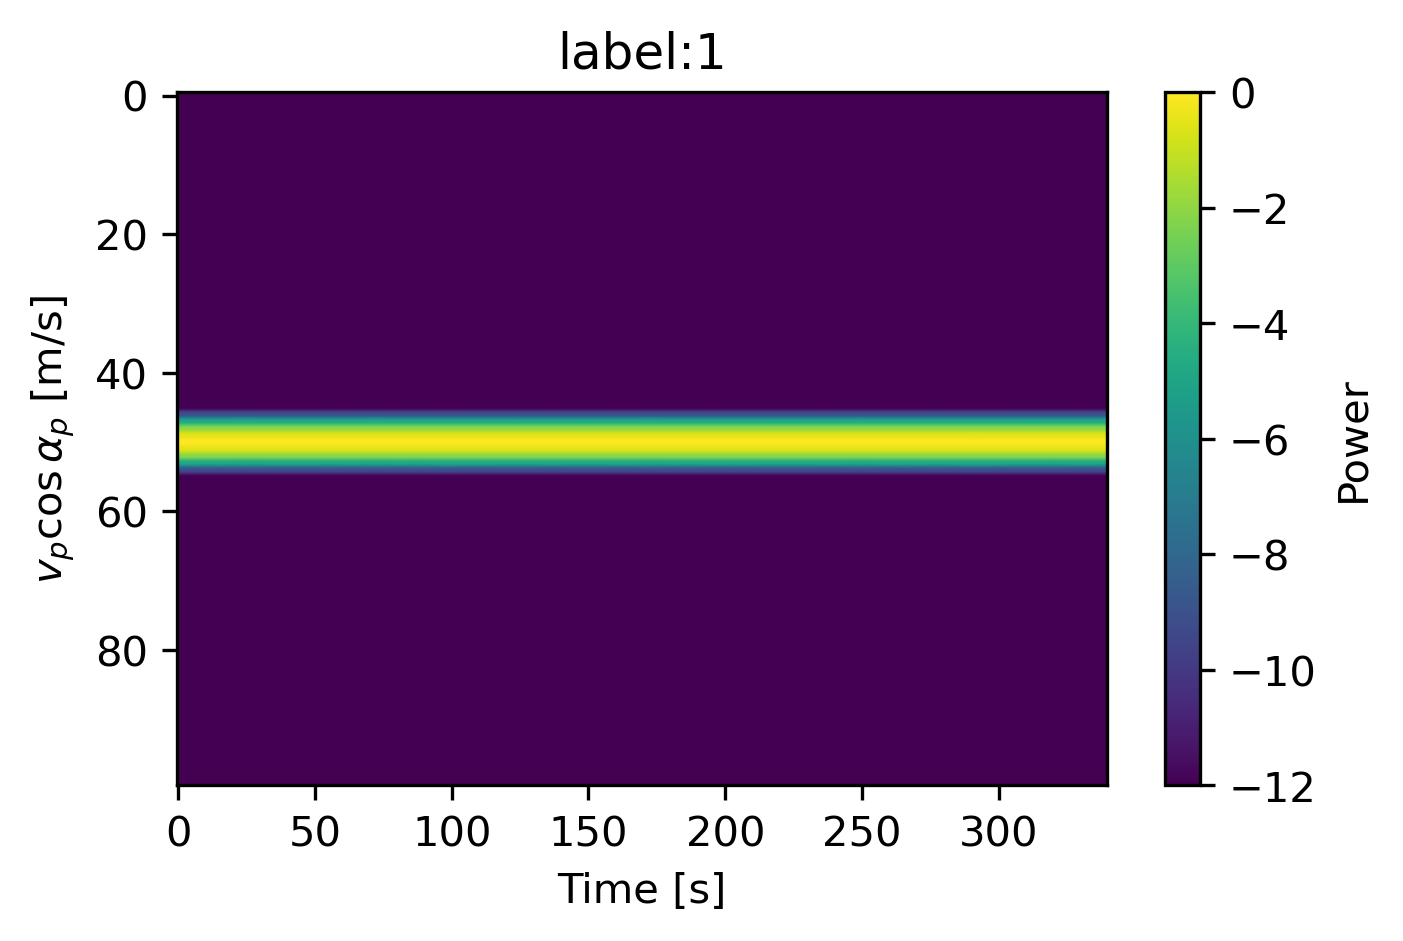

In [59]:
img, label = train_dataset[0]

fig, ax = plt.subplots(1, dpi=300, figsize=(5, 3))
image = ax.imshow(img.squeeze(dim=0), aspect='auto')
cb = fig.colorbar(image)
cb.set_label("Power")

ax.set_ylabel(r"$v_p \cos \alpha_p$ [m/s]", fontsize=10)
ax.set_xlabel("Time [s]", fontsize=10)
ax.set_title(f"label:{label}")

plt.show()

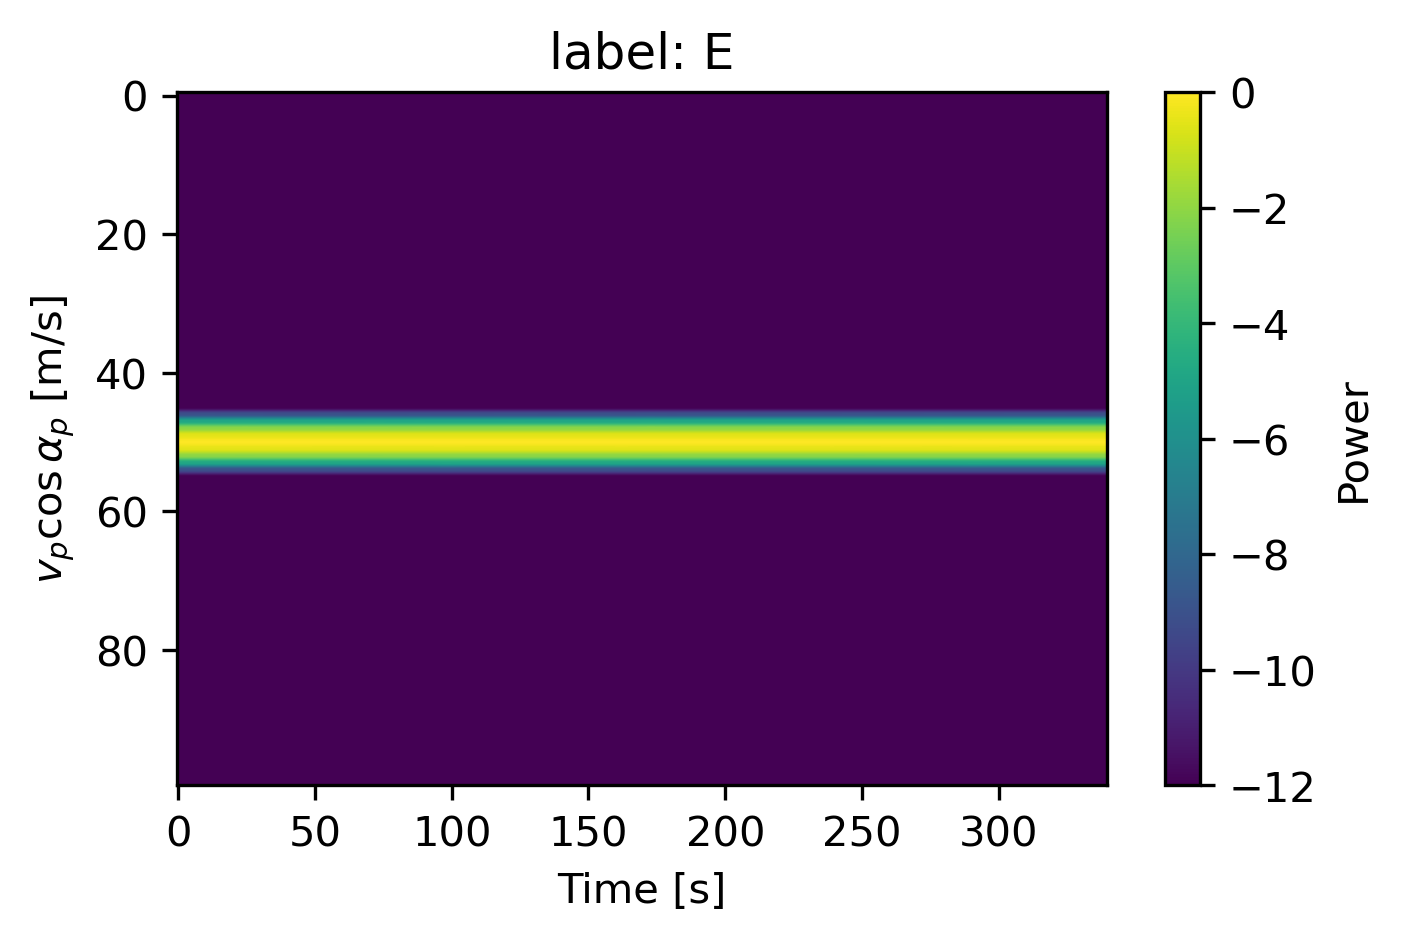

min=-12.0


In [54]:
img2 = np.load("doppler_traces_test/S2a_E_stream_0000.npy", allow_pickle=True).T
img2_db = 10*np.log10(img2)

fig, ax = plt.subplots(1, dpi=300, figsize=(5, 3))
image = ax.imshow(img2_db, aspect='auto')
cb = fig.colorbar(image)
cb.set_label("Power")

ax.set_ylabel(r"$v_p \cos \alpha_p$ [m/s]", fontsize=10)
ax.set_xlabel("Time [s]", fontsize=10)
ax.set_title(f"label: E")

plt.show()

print(f"min={img2_db.min()}")